In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix
from sklearn.decomposition import PCA

from utils import plot_dendrogram

In [2]:
dataset = pd.read_csv('Pokemon.csv').drop('#', axis = 1)

dataset.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [3]:
dataset.columns

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [4]:
dataset.isna().sum()

Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [5]:
dataset_num = dataset.select_dtypes(include= 'number')
dataset_cat = dataset.select_dtypes(exclude = 'number')

dataset_num.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,318,45,49,49,65,65,45,1
1,405,60,62,63,80,80,60,1
2,525,80,82,83,100,100,80,1
3,625,80,100,123,122,120,80,1
4,309,39,52,43,60,50,65,1


In [6]:
dataset_num.drop(['Total', 'Generation'], axis = 1, inplace=True)

In [7]:
dataset_num["physical_bulk"] = np.log1p(dataset["HP"] * dataset["Defense"])
dataset_num["special_bulk"] = np.log1p(dataset["HP"] * dataset["Sp. Def"])
dataset_num["best_offense"] = dataset[["Attack", "Sp. Atk"]].max(axis = 1)
dataset_num["offense_bias"] = dataset["Attack"] - dataset["Sp. Atk"]
dataset_num['defensive_bias'] = dataset['Defense'] - dataset['Sp. Def']

dataset_num

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,physical_bulk,special_bulk,best_offense,offense_bias,defensive_bias
0,45,49,49,65,65,45,7.698936,7.981392,65,-16,-16
1,60,62,63,80,80,60,8.237744,8.476580,80,-18,-17
2,80,82,83,100,100,80,8.801018,8.987322,100,-18,-17
3,80,100,123,122,120,80,9.194313,9.169623,122,-22,3
4,39,52,43,60,50,65,7.425358,7.576097,60,-8,-7
...,...,...,...,...,...,...,...,...,...,...,...
795,50,100,150,100,150,50,8.922792,8.922792,100,0,0
796,50,160,110,160,110,110,8.612685,8.612685,160,0,0
797,80,110,60,150,130,70,8.476580,9.249657,150,-40,-70
798,80,160,60,170,130,80,8.476580,9.249657,170,-10,-70


## Clustering using only the original features

In [8]:
dataset_num_original = dataset_num.drop(["physical_bulk","special_bulk", "best_offense", "offense_bias", "defensive_bias"], axis = 1)

dataset_num_new = dataset_num.drop(['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def'], axis = 1) #we maintain speed for the dataset with only the "new" features

In [9]:
scaler = StandardScaler()

num_scaled_original = scaler.fit_transform(dataset_num_original) #this returns by itself an array

#we need to put it as a dataframe so that we can merge with the categorical data
#num_scaled_original = pd.DataFrame(num_scaled_original, columns=dataset_num_original.columns, index = dataset.index)

#dataset_scaled_original = pd.concat([dataset_cat, num_scaled_original], axis=1)

In [10]:
pca = PCA(n_components=2) #we want to visualize in a 2D scatterplot

orginal_features_pca = pca.fit_transform(num_scaled_original)

pca_df = pd.DataFrame(
    orginal_features_pca,
    columns=['PC1', 'PC2']
)

pca_df['Name'] = dataset['Name']

**First let's apply KMeans**

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

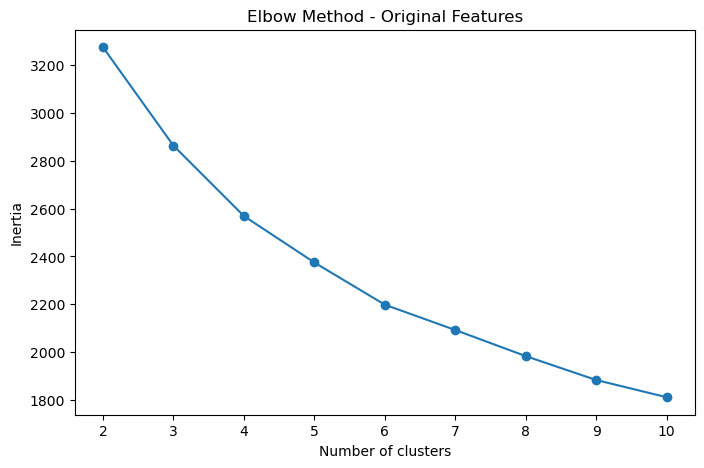

In [11]:
#Here we'll use the elbow method to find a good number of clusters, k.

inertias = []  

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_original)
    inertias.append(kmeans.inertia_)  #inertia tells how much information we loose by adding an extra cluster

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Original Features')
plt.show()

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

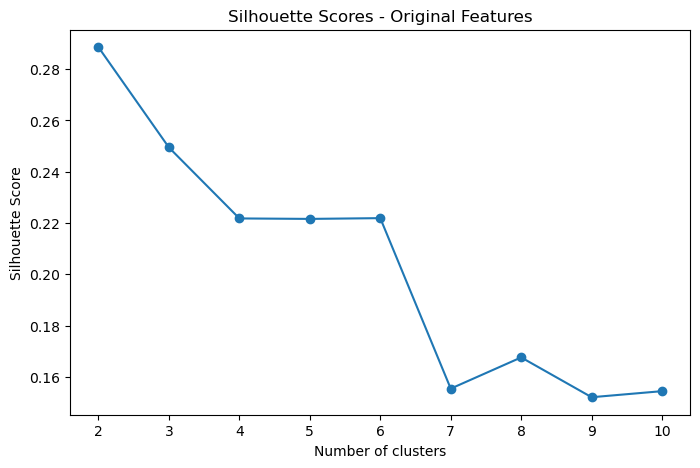

In [12]:
#Now using the silhouette score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_original)
    labels = kmeans.fit_predict(num_scaled_original)
    silhouette_scores.append(silhouette_score(num_scaled_original, labels))


plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - Original Features')
plt.show()

Let's interpret the clustering with k=4, and then test with k = 5 and k = 6

OK **NOTA IMPORTANTE:** Vamos usar k= 5 ou k = 6

In [13]:
kmeans = KMeans(n_clusters= 6, random_state=0).fit(num_scaled_original)
dataset_num_original['cluster_kmeans_original'] = kmeans.predict(num_scaled_original)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [14]:
dataset_num_original.groupby('cluster_kmeans_original').mean()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster_kmeans_original,,,,,,
0,65.883117,73.740260,66.077922,86.233766,75.051948,95.948052
1,79.701613,110.653226,85.274194,64.564516,70.653226,70.282258
2,50.261484,53.749117,52.084806,48.282686,49.448763,49.194346
3,90.849057,120.962264,94.037736,122.405660,98.688679,98.801887
4,61.358491,84.452830,139.811321,64.301887,96.660377,43.773585
5,103.400000,70.187500,77.575000,86.537500,95.312500,55.200000


The K-Means clustering using only the original features produced four distinct stat profiles. One cluster represented low-stat Pokémon, while another represented high-stat Pokémon with strong offensive and defensive attributes. A separate cluster showed a defensive profile, characterized by very high Defense and low Speed, suggesting a tank-like group. However, the results also indicate that clustering with original features is strongly influenced by overall stat magnitude, since some clusters reflect general strength rather than specific battle roles. This motivates the later use of engineered features to better capture role-based differences such as glass-cannon, tank, or sweeper profiles.

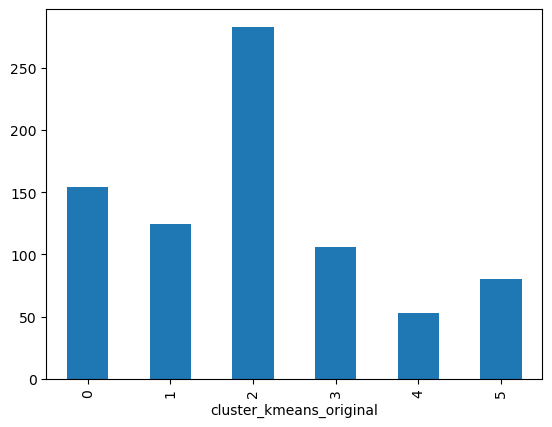

In [15]:
dataset_num_original.groupby(['cluster_kmeans_original']).size().plot(kind='bar')
plt.show()

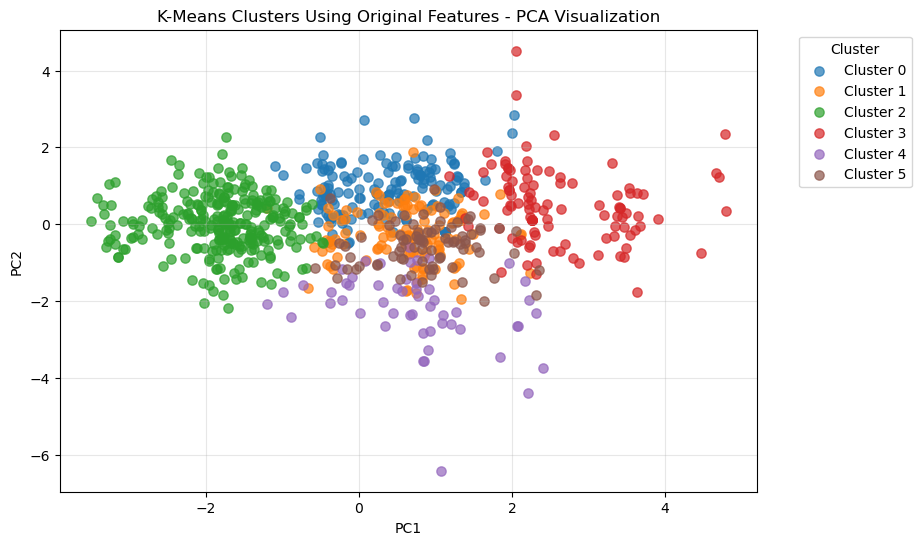

In [16]:
pca_df = pca_df.reset_index(drop=True)
dataset_num_original = dataset_num_original.reset_index(drop=True)

pca_df['cluster_kmeans_original'] = dataset_num_original['cluster_kmeans_original']


plt.figure(figsize=(9, 6))

clusters = sorted(pca_df['cluster_kmeans_original'].unique())

for cluster in clusters:
    cluster_data = pca_df[pca_df['cluster_kmeans_original'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=45
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters Using Original Features - PCA Visualization')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

In [17]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

[0.45190665 0.18225358]
Total variance explained: 0.6341602266029069


meter o que cada cluster representa em termos de grupo, exemplo, cluster 2 é o cluster de pokemons fracos, low-stats

!!!!!!!Now lets use **Hierarchical clustering** also only on the original features

In [18]:
hierarchical_original = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(num_scaled_original)

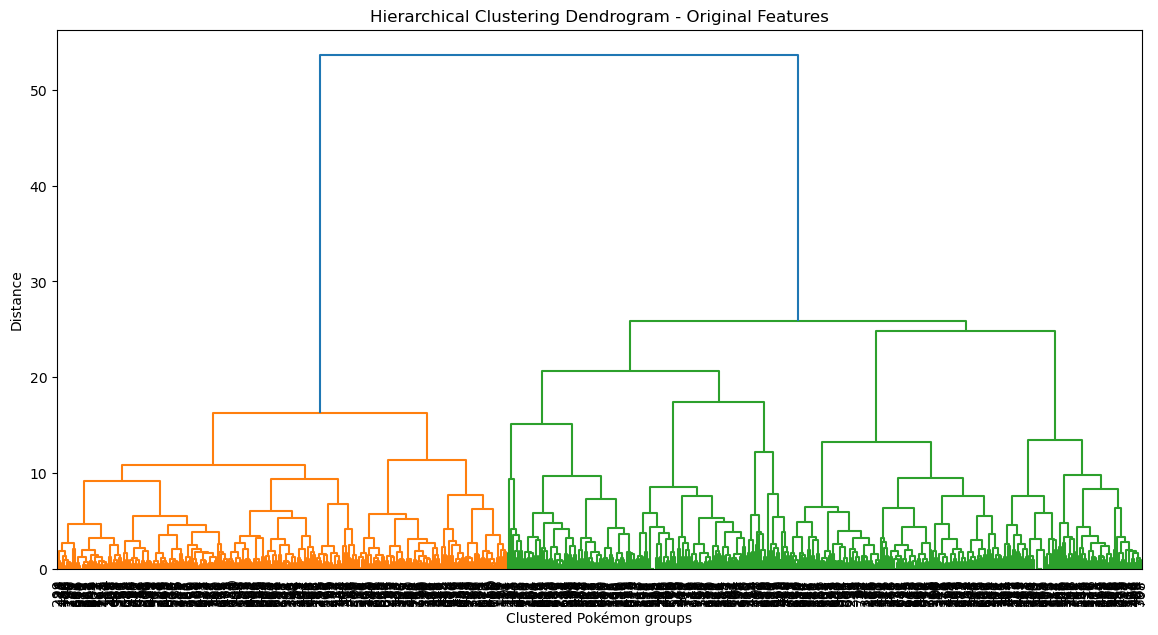

In [19]:
fig, ax = plt.subplots(figsize=(14,7))
plt.title("Hierarchical Clustering Dendrogram - Original Features")
# plot the top three levels of the dendrogram
plot_dendrogram(hierarchical_original, truncate_mode="level", p=20, leaf_rotation=90,leaf_font_size=10)


plt.xlabel("Clustered Pokémon groups")
plt.ylabel("Distance")
plt.show()

In [20]:
dataset_num_original['cluster_ward_original'] = AgglomerativeClustering(
    linkage='ward', n_clusters=6
    ).fit_predict(num_scaled_original)

In [21]:
pd.DataFrame(
    confusion_matrix(
        dataset_num_original['cluster_kmeans_original'],
        dataset_num_original['cluster_ward_original']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 6)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 6)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster
K-Means 0 Cluster,21,1,12,106,0,14
K-Means 1 Cluster,16,51,4,45,0,8
K-Means 2 Cluster,281,0,0,2,0,0
K-Means 3 Cluster,0,0,85,1,0,20
K-Means 4 Cluster,11,2,1,2,31,6
K-Means 5 Cluster,3,41,0,1,1,34


The comparison matrix shows partial agreement between K-Means and Hierarchical Clustering. Both algorithms strongly agree on one large group, corresponding to the low-stat Pokémon cluster. However, several other K-Means clusters are split across multiple hierarchical clusters, indicating that the separation of intermediate stat profiles is less stable. This suggests that, using only the original features, some Pokémon groups are clearly identifiable, while others depend more strongly on the clustering method used.

## Clustering using the engineered features

In [22]:
num_scaled_new = scaler.fit_transform(dataset_num_new)

In [23]:
pca = PCA(n_components=2) #we want to visualize in a 2D scatterplot

new_features_pca = pca.fit_transform(num_scaled_new)

pca_df_new = pd.DataFrame(
    new_features_pca,
    columns=['PC1', 'PC2']
)

pca_df_new['Name'] = dataset['Name']

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

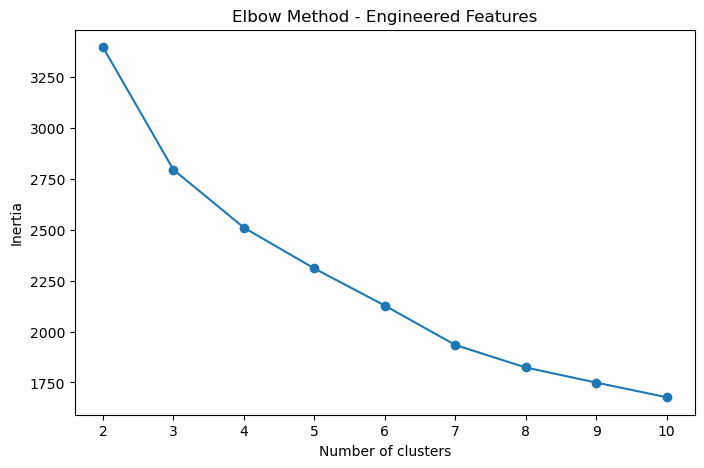

In [24]:
inertias = []  

K_range = range(2,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_new)
    inertias.append(kmeans.inertia_)  #inertia tells how much information we loose by adding an extra cluster

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method - Engineered Features')
plt.show()

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

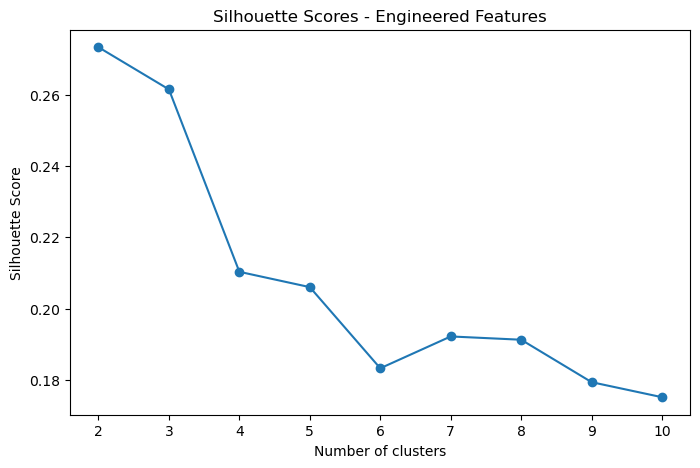

In [25]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled_new)
    labels = kmeans.fit_predict(num_scaled_new)
    silhouette_scores.append(silhouette_score(num_scaled_new, labels))


plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores - Engineered Features')
plt.show()

In [31]:
kmeans = KMeans(n_clusters= 3, random_state=0).fit(num_scaled_new)
dataset_num_new['cluster_kmeans_engineered'] = kmeans.predict(num_scaled_new)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [32]:
dataset_num_new.groupby('cluster_kmeans_engineered').mean().round(2)

,Speed,physical_bulk,special_bulk,best_offense,offense_bias,defensive_bias
cluster_kmeans_engineered,,,,,,
0,81.88,8.65,8.81,101.53,-17.29,-12.38
1,50.44,7.77,7.72,60.71,6.00,3.56
2,72.81,8.90,8.63,114.54,47.68,24.51


The engineered-feature clustering with k=3 produced three interpretable groups.
Cluster 0 contains faster and relatively balanced Pokémon with good offensive capability and slightly stronger special bulk.
Cluster 1 groups physically oriented Pokémon with the highest offensive output, strongest physical bulk, and stronger physical than special defense.
Cluster 2 includes slower and less offensively powerful Pokémon, with lower bulk and a more balanced but less specialized profile.
Overall, the engineered features appear to produce clusters that are easier to interpret in terms of Pokémon battle roles.

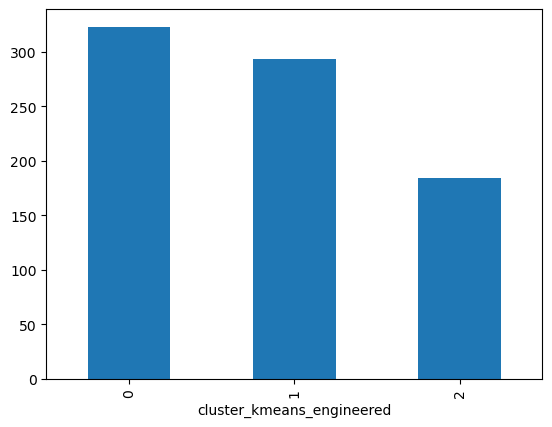

In [33]:
dataset_num_new.groupby(['cluster_kmeans_engineered']).size().plot(kind='bar')
plt.show()

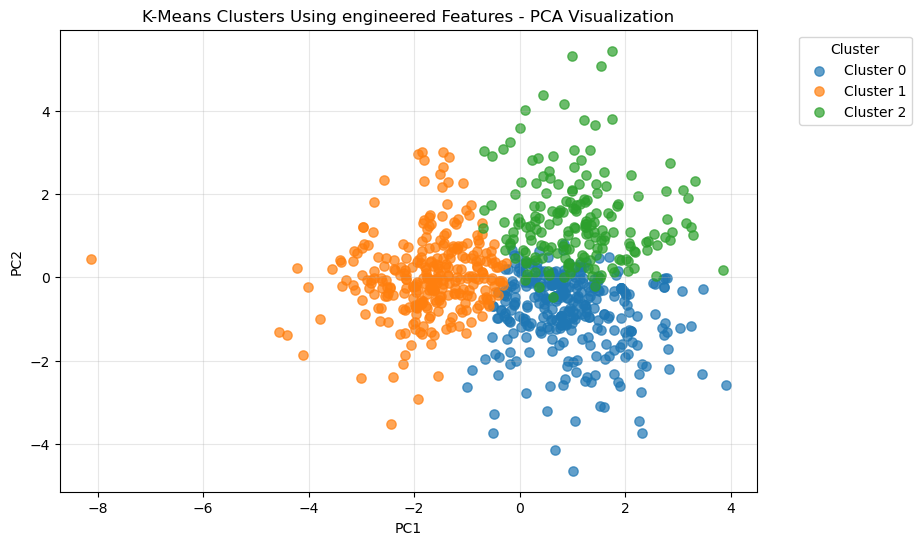

In [34]:
pca_df_new = pca_df_new.reset_index(drop=True)
dataset_num_new = dataset_num_new.reset_index(drop=True)

pca_df_new['cluster_kmeans_engineered'] = dataset_num_new['cluster_kmeans_engineered']


plt.figure(figsize=(9, 6))

clusters = sorted(pca_df_new['cluster_kmeans_engineered'].unique())

for cluster in clusters:
    cluster_data = pca_df_new[pca_df_new['cluster_kmeans_engineered'] == cluster]
    
    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=45
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters Using engineered Features - PCA Visualization')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()

In [35]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

[0.41725561 0.27073667]
Total variance explained: 0.6879922754344947


In [36]:
hierarchical_engineered = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(num_scaled_new)

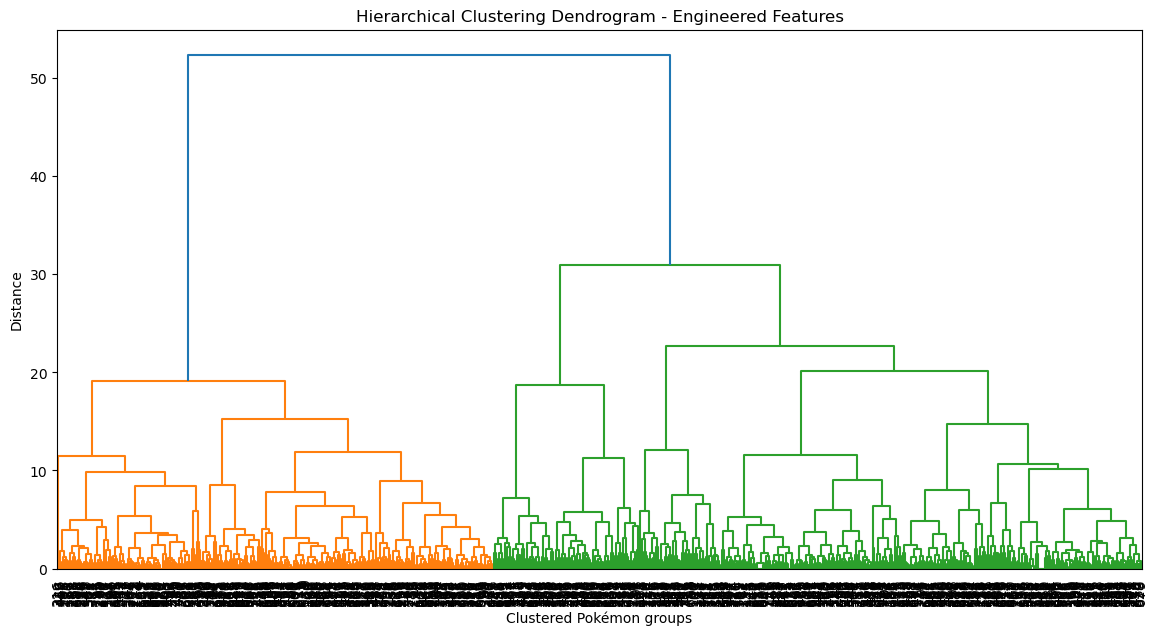

In [37]:
fig, ax = plt.subplots(figsize=(14,7))
plt.title("Hierarchical Clustering Dendrogram - Engineered Features")
# plot the top three levels of the dendrogram
plot_dendrogram(hierarchical_engineered, truncate_mode="level", p=20, leaf_rotation=90,leaf_font_size=10)


plt.xlabel("Clustered Pokémon groups")
plt.ylabel("Distance")
plt.show()

In [39]:
dataset_num_new['cluster_ward_engineered'] = AgglomerativeClustering(
    linkage='ward', n_clusters=3
    ).fit_predict(num_scaled_new)

In [41]:
pd.DataFrame(
    confusion_matrix(
        dataset_num_new['cluster_kmeans_engineered'],
        dataset_num_new['cluster_ward_engineered']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 3)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 3)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster
K-Means 0 Cluster,284,20,12
K-Means 1 Cluster,61,15,95
K-Means 2 Cluster,26,287,0


## Deixei esta parte, não mexi nada henrique

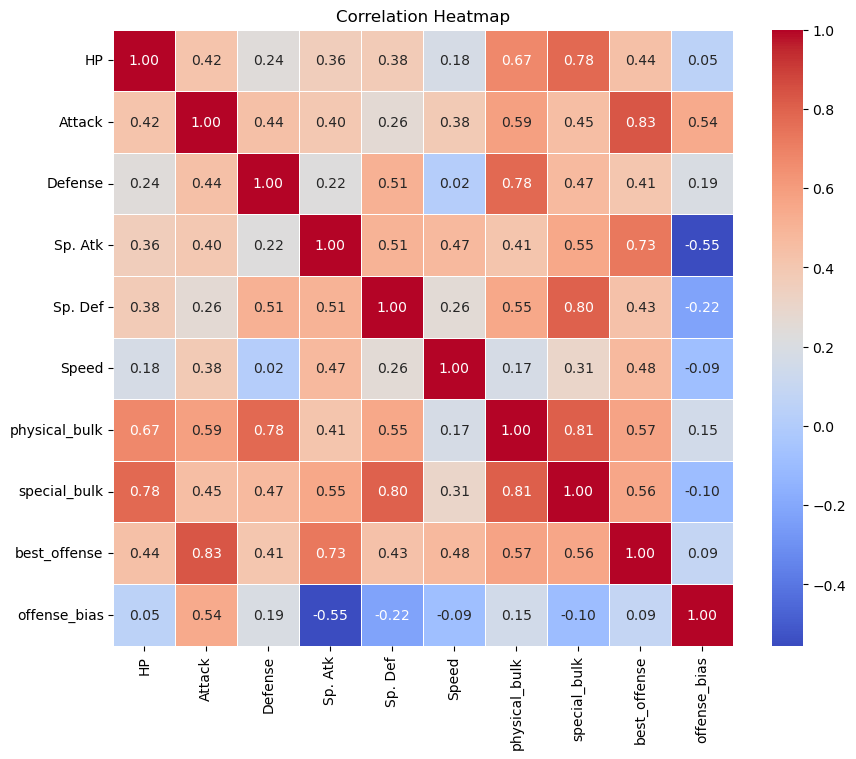

Top 5 feature combinations with highest correlation:
Attack & best_offense: 0.831 (abs: 0.831)
physical_bulk & special_bulk: 0.811 (abs: 0.811)
Sp. Def & special_bulk: 0.800 (abs: 0.800)
Defense & physical_bulk: 0.778 (abs: 0.778)
HP & special_bulk: 0.777 (abs: 0.777)


In [84]:
corr = dataset_num.corr()

plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Get the upper triangle of the correlation matrix (excluding self-correlations on the diagonal)
corr_upper = corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))

# Stack the correlations into a Series with multi-index (feature pairs)
corr_pairs = corr_upper.stack()

# Sort by absolute correlation value (highest first) and take top 5
top_5 = corr_pairs.abs().sort_values(ascending=False).head(5)

print("Top 5 feature combinations with highest correlation:")
for (feat1, feat2), abs_corr in top_5.items():
    actual_corr = corr_pairs.loc[(feat1, feat2)]
    print(f"{feat1} & {feat2}: {actual_corr:.3f} (abs: {abs_corr:.3f})")

In [ ]:
scaler = StandardScaler()

num_scaled = scaler.fit_transform(dataset_num) #this returns by itself an array

#we need to put it as a dataframe so that we can merge with the categorical data
num_scaled = pd.DataFrame(num_scaled_original, columns=dataset_num.columns, index = dataset.index)

dataset_scaled = pd.concat([dataset_cat, num_scaled], axis=1)

In [86]:
k_range = range(2,11)

dispersion = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled)
    dispersion.append(kmeans.inertia_)

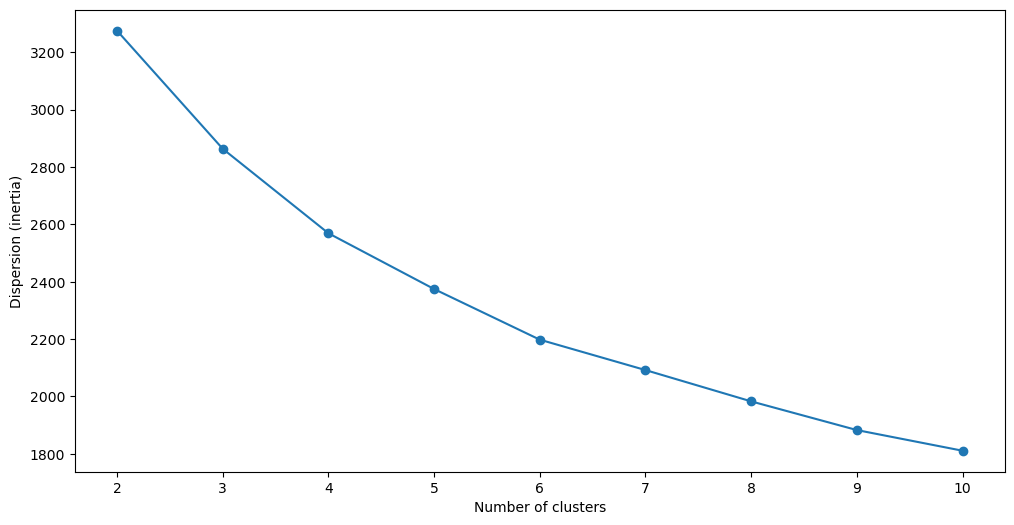

In [72]:
plt.figure(figsize=(12,6))
plt.plot(k_range, dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

In [87]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(num_scaled)
    score = silhouette_score(num_scaled, labels)
    silhouette_scores.append(score)

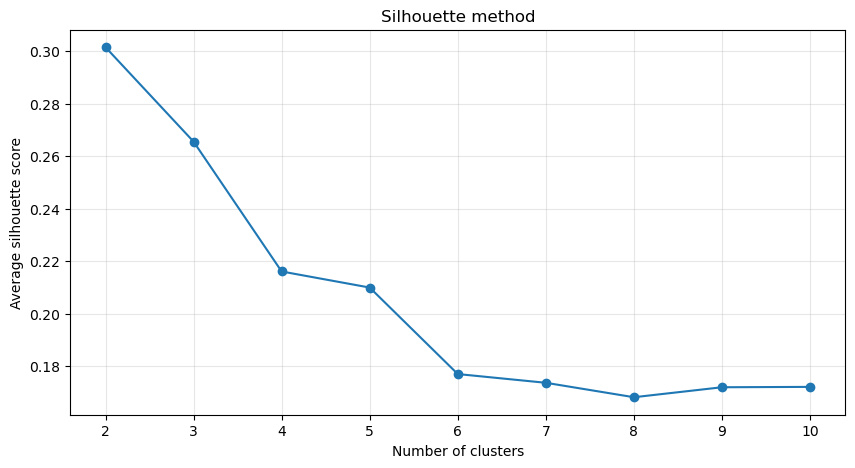

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Average silhouette score')
plt.title('Silhouette method')
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
# Get indices of silhouette scores sorted from highest to lowest
top3_idx = np.argsort(silhouette_scores)[::-1][:3]

# Convert those indices into actual k values
top3_k = [k_range[i] for i in top3_idx]

print("Top 3 cluster counts:", top3_k)
print("Corresponding silhouette scores:", [silhouette_scores[i] for i in top3_idx])

Top 3 cluster counts: [2, 3, 4]
Corresponding silhouette scores: [0.3014890149010586, 0.2655200561642888, 0.2160658053250472]


In [96]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(num_scaled)

In [107]:
#Não percebi isto!
dataset_new = dataset.groupby("cluster")[["physical_bulk", "special_bulk", "best_offense", "offense_bias"]].mean()
dataset_new

,physical_bulk,special_bulk,best_offense,offense_bias
cluster,,,,
0,8.706043,8.641612,114.056180,52.213483
1,7.929176,7.763413,59.442857,8.550000
2,8.422360,8.576529,112.804348,-23.293478
3,8.898408,8.983068,96.655172,-11.885057
4,7.370241,7.465588,59.398148,5.435185
5,9.166596,8.479735,107.562500,45.083333
6,8.776862,8.835234,80.923077,-8.564103
7,8.689904,9.295415,78.909091,7.727273
8,8.272779,8.330437,79.466102,-1.932203


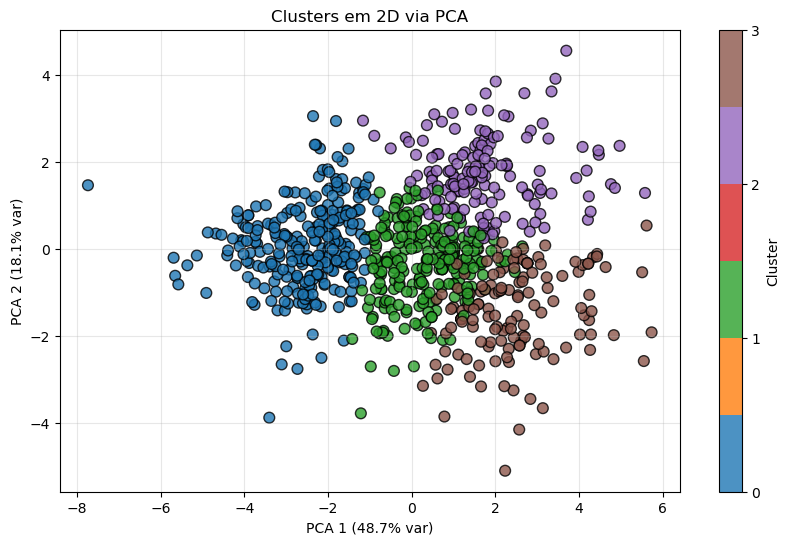

In [106]:
cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [99]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(num_scaled)

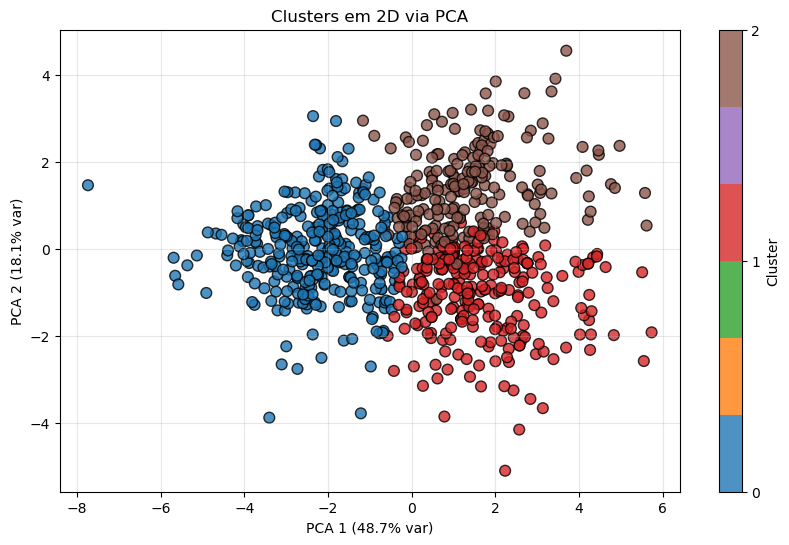

In [100]:
cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [103]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(num_scaled)

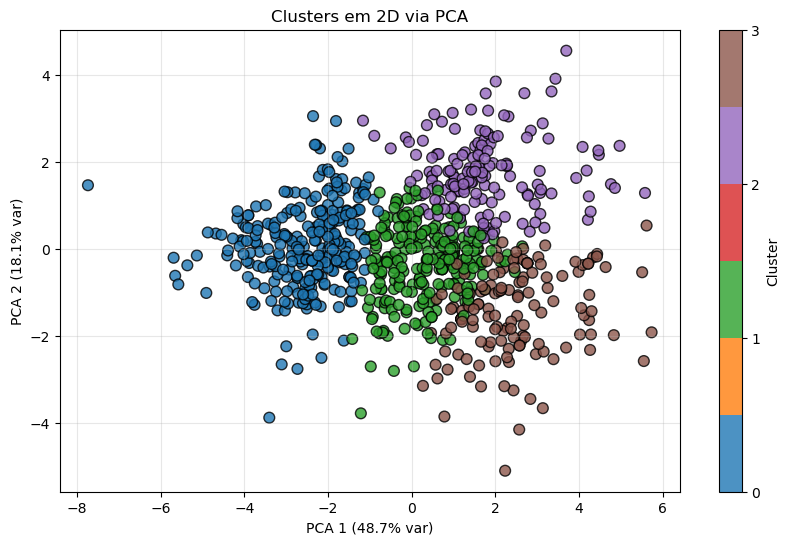

In [104]:
cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

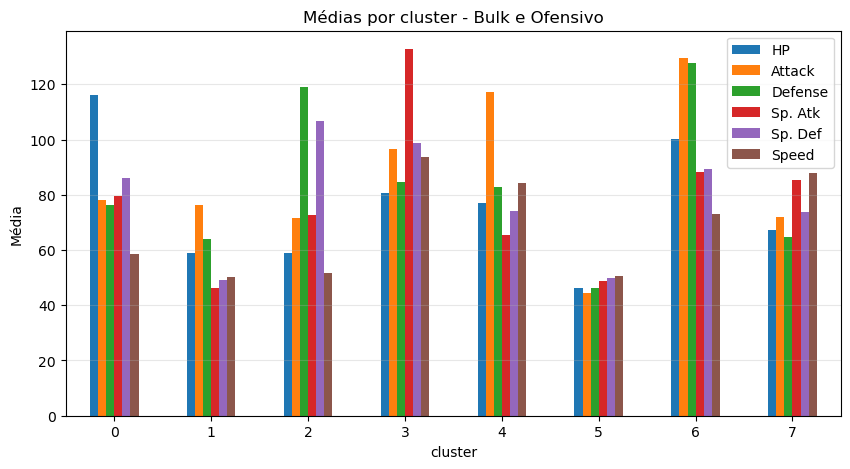

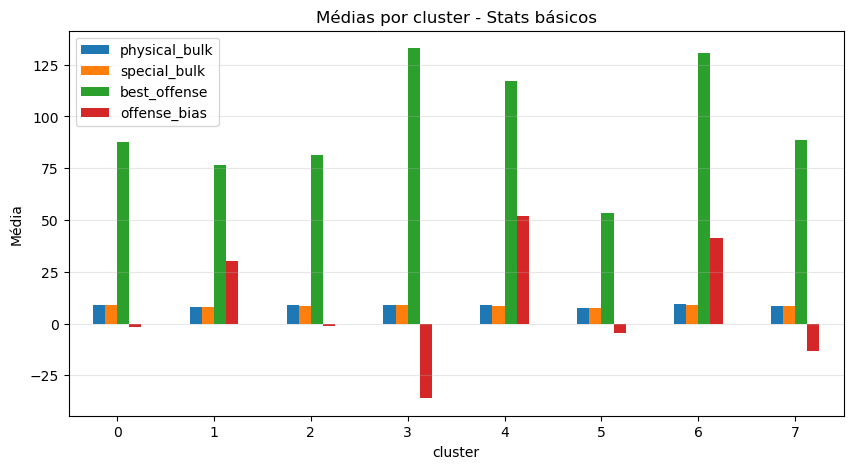

In [ ]:
dataset_original.plot(kind='bar', figsize=(10, 5))
plt.title('Médias por cluster - Bulk e Ofensivo')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

dataset_new.plot(kind='bar', figsize=(10, 5))
plt.title('Médias por cluster - Stats básicos')
plt.ylabel('Média')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
#TESTE

In [ ]:
# Create more meaningful features
dataset["physical_bulk"] = np.log1p(dataset["HP"] * dataset["Defense"])
dataset["special_bulk"] = np.log1p(dataset["HP"] * dataset["Sp. Def"])
dataset["best_offense"] = dataset[["Attack", "Sp. Atk"]].max(axis=1)
dataset["offense_bias"] = dataset["Attack"] - dataset["Sp. Atk"]

# Use only relevant features
features_to_use = ["physical_bulk", "special_bulk", "best_offense", "offense_bias", "Speed"]
num_scaled = scaler.fit_transform(dataset[features_to_use])

In [ ]:
# Try MinMaxScaler instead of StandardScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(dataset_num)

In [ ]:
# Hierarchical clustering often gives better results
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels = agg.fit_predict(num_scaled)

In [ ]:
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
labels = kmeans.fit_predict(num_scaled)

In [ ]:
# Remove extreme values that mess up clusters
Q1 = dataset_num.quantile(0.25)
Q3 = dataset_num.quantile(0.75)
IQR = Q3 - Q1
dataset_clean = dataset_num[~((dataset_num < (Q1 - 1.5 * IQR)) | (dataset_num > (Q3 + 1.5 * IQR))).any(axis=1)]

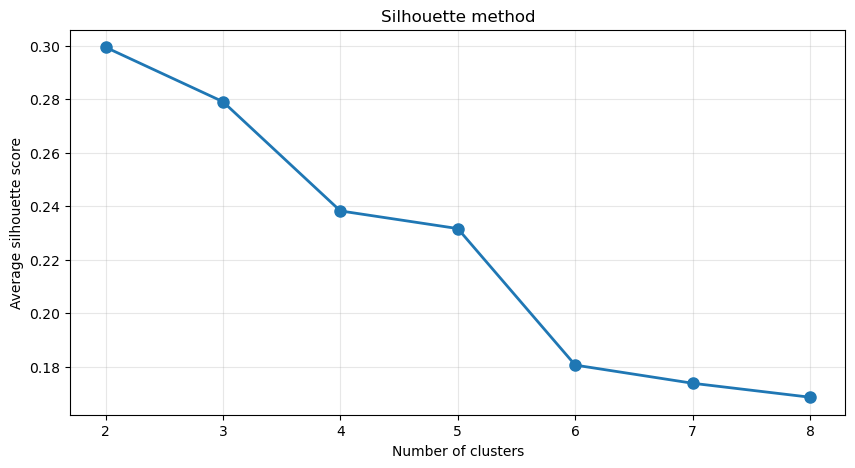

Best number of clusters: 2
Best silhouette score: 0.299


In [ ]:
from sklearn.metrics import silhouette_score, silhouette_samples

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(num_scaled)
    score = silhouette_score(num_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of clusters')
plt.ylabel('Average silhouette score')
plt.title('Silhouette method')
plt.grid(True, alpha=0.3)
plt.show()

# Find the best k
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

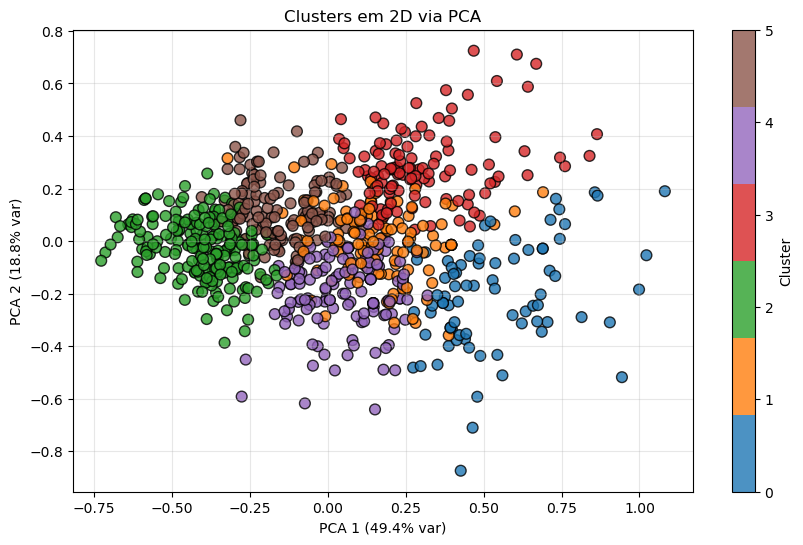

In [ ]:
# Set clusters to 2
best_k = 6

# Re-run KMeans with best_k=2
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(num_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

# Visualize
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'])

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=labels,
            cmap=cmap,
            s=60,
            alpha=0.8,
            edgecolor='k')

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('Clusters em 2D via PCA')
plt.colorbar(ticks=range(len(np.unique(labels))), label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

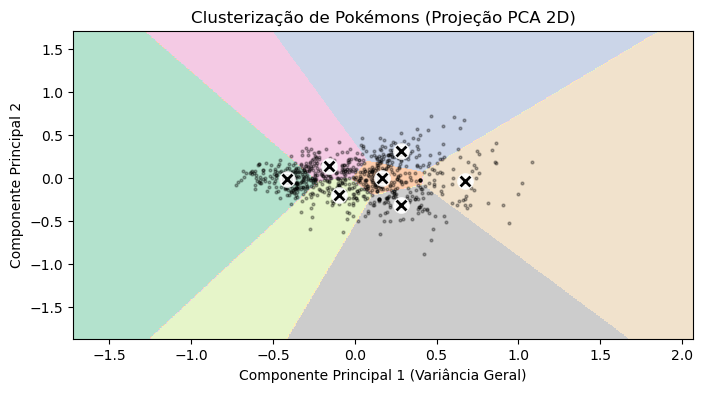

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=4, alpha=0.3)

def plot_centroids(centroids, weights=None):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]

    plt.scatter(centroids[:, 0], centroids[:, 1], marker='o', s=100, linewidths=2, color='w', zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=50, linewidths=2, color='k', zorder=11, alpha=1)

def plot_clusters(clusterer, X):
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1
    res = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, res), np.arange(y_min, y_max, res))

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(xx.min(), xx.max(), yy.min(), yy.max()), 
                 cmap=plt.cm.Pastel2, origin='lower')

    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)

    plt.title("Clusterização de Pokémons (Projeção PCA 2D)")
    plt.xlabel("Componente Principal 1 (Variância Geral)")
    plt.ylabel("Componente Principal 2")


pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

kmeans_pca = KMeans(n_clusters=7, n_init=10, random_state=42)
kmeans_pca.fit(X_pca)

plt.figure(figsize=(8,4))
plot_clusters(kmeans_pca, X_pca)
plt.show()